# Chapter 7 Variational Inference
## Author: Rahul Bhadani

# 1. AutoEncoder on MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Device configuration (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Hyperparameters
batch_size = 128
learning_rate = 1e-3
num_epochs = 20
latent_dim = 32  # Dimension of the bottleneck

In [3]:
# MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1] and shape (1,28,28)
])

train_dataset = datasets.MNIST(root='.,/Data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='../Data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 810kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.63MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 24.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 914kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.27MB/s]


Epoch [1/20], Loss: 0.0500
Epoch [2/20], Loss: 0.0244
Epoch [3/20], Loss: 0.0188
Epoch [4/20], Loss: 0.0154
Epoch [5/20], Loss: 0.0132
Epoch [6/20], Loss: 0.0119
Epoch [7/20], Loss: 0.0109
Epoch [8/20], Loss: 0.0101
Epoch [9/20], Loss: 0.0095
Epoch [10/20], Loss: 0.0089
Epoch [11/20], Loss: 0.0084
Epoch [12/20], Loss: 0.0080
Epoch [13/20], Loss: 0.0077
Epoch [14/20], Loss: 0.0074
Epoch [15/20], Loss: 0.0072
Epoch [16/20], Loss: 0.0070
Epoch [17/20], Loss: 0.0068
Epoch [18/20], Loss: 0.0067
Epoch [19/20], Loss: 0.0065
Epoch [20/20], Loss: 0.0064


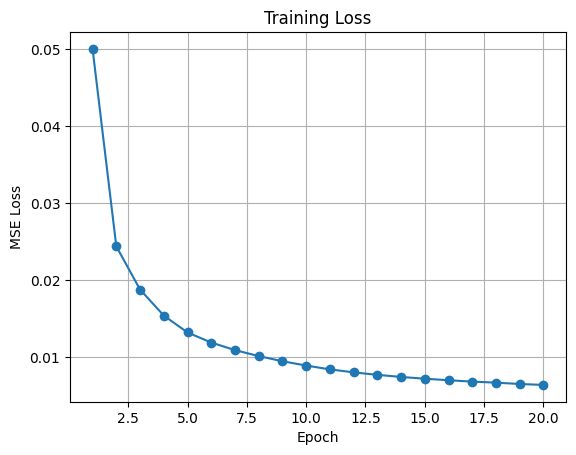

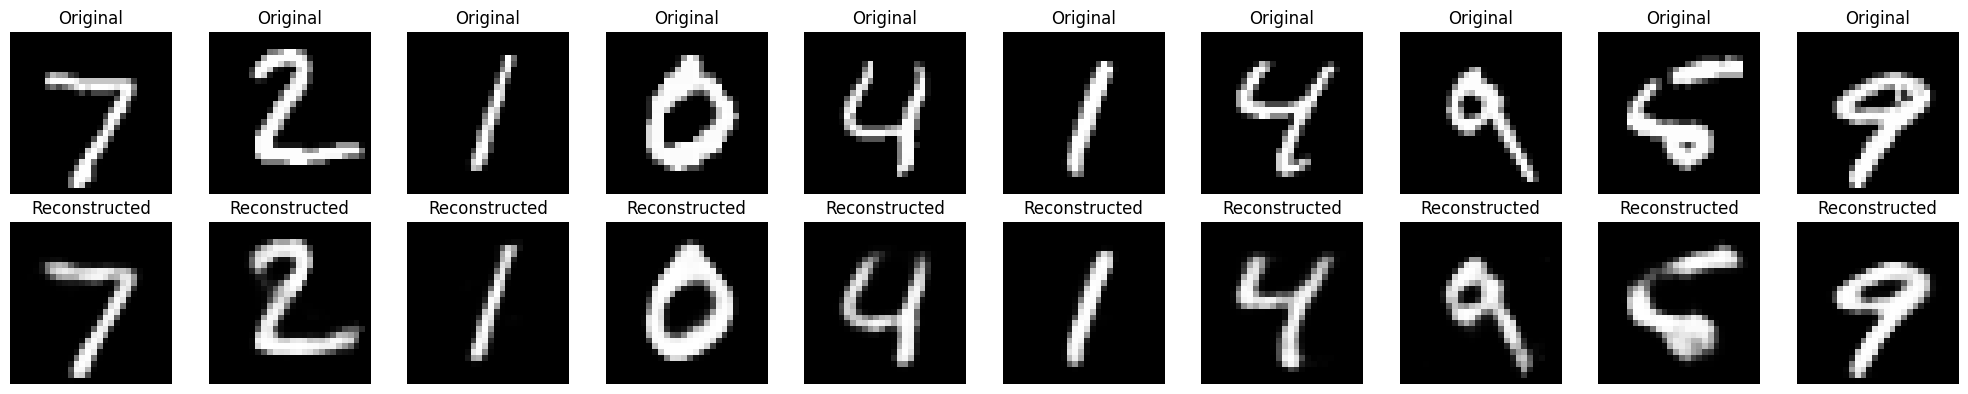

In [4]:
# Define the autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        # Encoder: fully connected layers
        self.encoder = nn.Sequential(
            nn.Flatten(),                       # (batch, 1,28,28) -> (batch, 784)
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)          # bottleneck
        )
        
        # Decoder: fully connected layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()                         # output in [0,1] for pixel values
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        # Reshape back to image shape (batch, 1, 28, 28)
        reconstructed = reconstructed.view(-1, 1, 28, 28)
        return reconstructed

model = Autoencoder(latent_dim).to(device)

# Loss function and optimizer
criterion = nn.MSELoss()  # or nn.BCELoss() – both work. MSE is simpler here.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
train_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, _ in train_loader:   # we ignore labels
        images = images.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, images)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
    
    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Plot training loss
plt.figure()
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# Evaluate on test set and visualize reconstructions
model.eval()
with torch.no_grad():
    # Get a batch of test images
    images, _ = next(iter(test_loader))
    images = images.to(device)
    reconstructed = model(images)

    # Move to CPU for plotting
    images = images.cpu()
    reconstructed = reconstructed.cpu()

# Plot original and reconstructed images side by side
n = 10  # number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 2. Variational Inference

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


In [37]:
# Generate synthetic data
torch.manual_seed(42)
N = 100
true_mean = 3.0
sigma = 1.0
data = torch.randn(N) * sigma + true_mean

# Prior parameters: this is what I think before seeing the data
mu_0 = 0.0
sigma_0 = 5.0

In [38]:
# Variational parameters to optimize
m = nn.Parameter(torch.tensor(0.0))
log_s = nn.Parameter(torch.tensor(0.0))


In [39]:
optimizer = optim.Adam([m, log_s], lr=0.05)

KL divergencce between two Gaussians
$$
KL = \log(\cfrac{\sigma_0}{s}) + s^2 + \cfrac{(m - \mu_0)^2}{2\sigma_0^2} - 0.5
$$

In [40]:
def kl_gaussian(m, log_s, mu_0, sigma_0):
    s = torch.exp(log_s)
    kl = torch.log(sigma_0 / s) + (s**2 + (m - mu_0)**2) / (2 * sigma_0**2) - 0.5
    return kl


In [41]:
L = 10  # number of Monte Carlo samples for expectation
num_epochs = 1000

elbo_vals = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Sample epsilon
    eps = torch.randn(L)
    theta = m + torch.exp(log_s) * eps  # shape (L,)
    
    # Expected log-likelihood (over samples)
    log_lik = torch.distributions.Normal(theta.unsqueeze(1), sigma).log_prob(data)  # (L, N)

    exp_log_lik = log_lik.mean(dim=0).sum()   # sum over data points
    
    # KL term
    kl = kl_gaussian(m, log_s, mu_0, sigma_0)
    
    # ELBO (to maximize)
    elbo = exp_log_lik - kl
    (-elbo).backward()  # minimize negative ELBO
    optimizer.step()
    
    elbo_vals.append(elbo.item())

Estimated mean: 3.056 (true 3.0)
Estimated std: 0.098


Text(0.5, 1.0, 'ELBO during optimization')

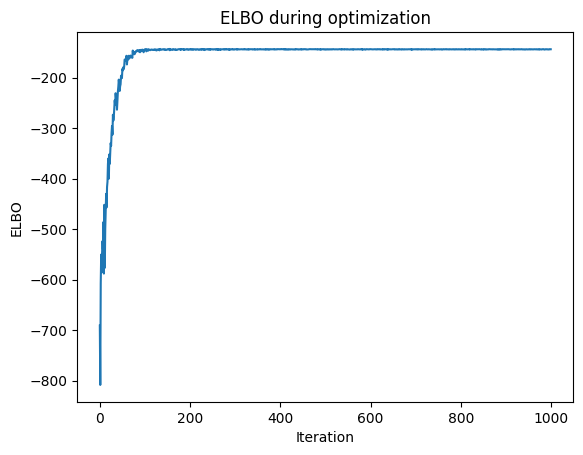

In [42]:
print(f"Estimated mean: {m.item():.3f} (true {true_mean})")
print(f"Estimated std: {torch.exp(log_s).item():.3f}")

plt.plot(elbo_vals)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("ELBO during optimization")
#plt.show()

In [43]:
# true posterior
sigma_post_sq = 1.0 / (N / sigma**2 + 1.0 / sigma_0**2)
sigma_post = np.sqrt(sigma_post_sq)
mu_post = sigma_post_sq * (data.sum().item() / sigma**2 + mu_0 / sigma_0**2)

# --- Learned variational params ---
m_learned = m.item()
s_learned = torch.exp(log_s).item()

print(f"True posterior:  mean = {mu_post:.4f}, std = {sigma_post:.4f}")
print(f"Learned q:       mean = {m_learned:.4f}, std = {s_learned:.4f}")


True posterior:  mean = 3.0585, std = 0.1000
Learned q:       mean = 3.0565, std = 0.0980


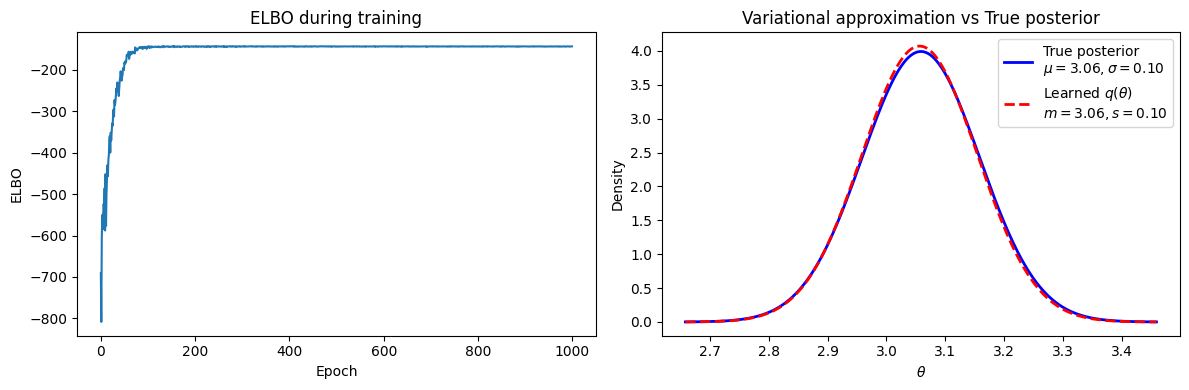

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: ELBO curve
ax1.plot(elbo_vals)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("ELBO")
ax1.set_title("ELBO during training")

# Right: learned q vs true posterior vs prior
theta_range = np.linspace(mu_post - 4*sigma_post, mu_post + 4*sigma_post, 300)

from scipy.stats import norm
ax2.plot(theta_range, norm.pdf(theta_range, mu_post, sigma_post),
            label=f"True posterior\n$\\mu={mu_post:.2f}, \\sigma={sigma_post:.2f}$",
            color="blue", linewidth=2)
ax2.plot(theta_range, norm.pdf(theta_range, m_learned, s_learned),
            label=f"Learned $q(\\theta)$\n$m={m_learned:.2f}, s={s_learned:.2f}$",
            color="red", linewidth=2, linestyle="--")
ax2.set_xlabel("$\\theta$")
ax2.set_ylabel("Density")
ax2.set_title("Variational approximation vs True posterior")
ax2.legend()

plt.tight_layout()
plt.show()

# 3. Bayesian Logistics Regression

We consider a more interesting example: binary classification with Bayesian logistic
regression. We have data $\{(x_i, y_i)\}_{i=1}^N$ with $x_i \in \mathbb{R}^D$ and $y_i \in \{0, 1\}$.

### Model

- **Likelihood:** $p(y_i | x_i, w) = \sigma(w^\top x_i)^{y_i} (1 - \sigma(w^\top x_i))^{1-y_i}$, where $\sigma(\cdot)$ is the sigmoid function.
- **Prior:** isotropic Gaussian $p(w) = \mathcal{N}(w; 0, \alpha^{-1} I)$, with precision $\alpha$.

An isotropic Gaussian is a multivariate Gaussian where the covariance matrix is a scalar multiple of the identity. "Isotropic" means equal variance in all directions, i.e. the distribution has the same spread along every axis, and all dimensions are independent. Geometrically, its contours are perfect spheres (in 3D) or hyperspheres (in higher dimensions).

An isotropic Gaussian is a special case of diagonal Gaussian where covariance matrix has non-diagonal elements zero.

### Variational Family

We use a mean-field Gaussian: $q(w) = \prod_{d=1}^D \mathcal{N}(w_d; m_d, s_d^2)$, parameterized by $m$ and $\log s$ vectors.

### ELBO

**KL divergence** between two diagonal Gaussians:

$$
\text{KL}(q \| p) = \sum_{d=1}^D \left[ \log \frac{1/\sqrt{\alpha}}{s_d} + \frac{s_d^2 + m_d^2}{2(1/\alpha)} - \frac{1}{2} \right].
$$

**Expected log-likelihood** approximated via reparameterization:

$$
\mathbb{E}_q[\log p(\mathcal{D}|w)] \approx \frac{1}{L} \sum_{l=1}^L \sum_{i=1}^N \left[ y_i \log \sigma(w^{(l)\top} x_i) + (1 - y_i) \log(1 - \sigma(w^{(l)\top} x_i)) \right],
$$

with $w^{(l)} = m + s \odot \epsilon^{(l)}$, $\epsilon^{(l)} \sim \mathcal{N}(0, I)$.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, 
                        n_clusters_per_class=1, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

N, D = X.shape

# Prior precision
alpha = 1.0

In [3]:
N, D

(1000, 2)

In [4]:
# Variational parameters
m = nn.Parameter(torch.zeros(D))
log_s = nn.Parameter(torch.zeros(D))

In [5]:
optimizer = optim.Adam([m, log_s], lr=0.01)

Final variational mean: [0.05767045 3.1879842 ]
Final variational std: [0.07931916 0.22099447]


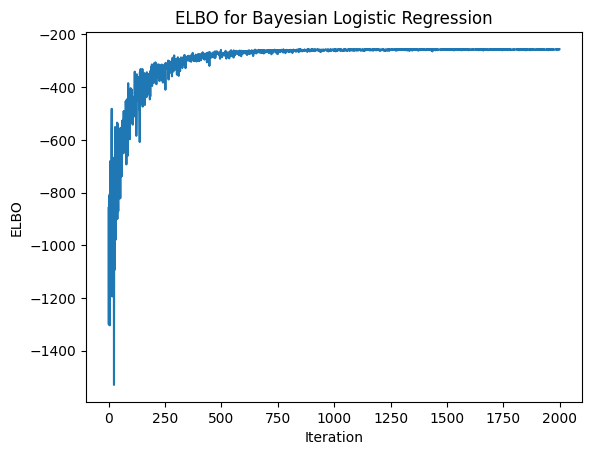

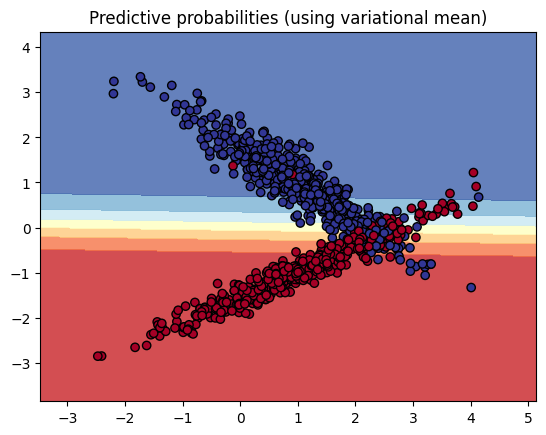

In [6]:
def kl_gaussian_diag(m, log_s, alpha):
    s = torch.exp(log_s)
    prior_var = 1.0 / alpha
    kl = torch.sum(torch.log(prior_var**0.5 / s) + (s**2 + m**2) / (2 * prior_var) - 0.5)
    return kl

L = 5  # Monte Carlo samples
num_epochs = 2000

elbo_vals = []

m_history    = []   # shape: (num_epochs, D)
s_history    = []   # shape: (num_epochs, D)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Reparameterization
    eps = torch.randn(L, D)
    w = m + torch.exp(log_s) * eps  # (L, D)
    
    # Compute logits for all samples
    logits = torch.matmul(w, X.T)  # (L, N)
    # Expected log-likelihood (binary cross-entropy with sigmoid)
    # We'll use BCEWithLogitsLoss, which combines sigmoid and BCE
    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    loss_per_sample = loss_fn(logits, y.unsqueeze(0).expand(L, -1))  # (L, N)
    exp_log_lik = -loss_per_sample.mean(dim=0).sum()  # negative loss = log-likelihood
    
    # KL
    kl = kl_gaussian_diag(m, log_s, alpha)
    
    elbo = exp_log_lik - kl
    (-elbo).backward()
    optimizer.step()
    
    elbo_vals.append(elbo.item())
    
    m_history.append(m.detach().clone().numpy())
    s_history.append(torch.exp(log_s).detach().clone().numpy())

print(f"Final variational mean: {m.detach().numpy()}")
print(f"Final variational std: {torch.exp(log_s).detach().numpy()}")

plt.plot(elbo_vals)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("ELBO for Bayesian Logistic Regression")
plt.show()

# Visualize decision boundary
w_mean = m.detach().numpy()
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = np.dot(np.c_[xx.ravel(), yy.ravel()], w_mean)
Z = 1 / (1 + np.exp(-Z))
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
plt.title("Predictive probabilities (using variational mean)")
plt.show()

Why is Baysian Logistics Regression better than Simple Logisitics Regression, see below:

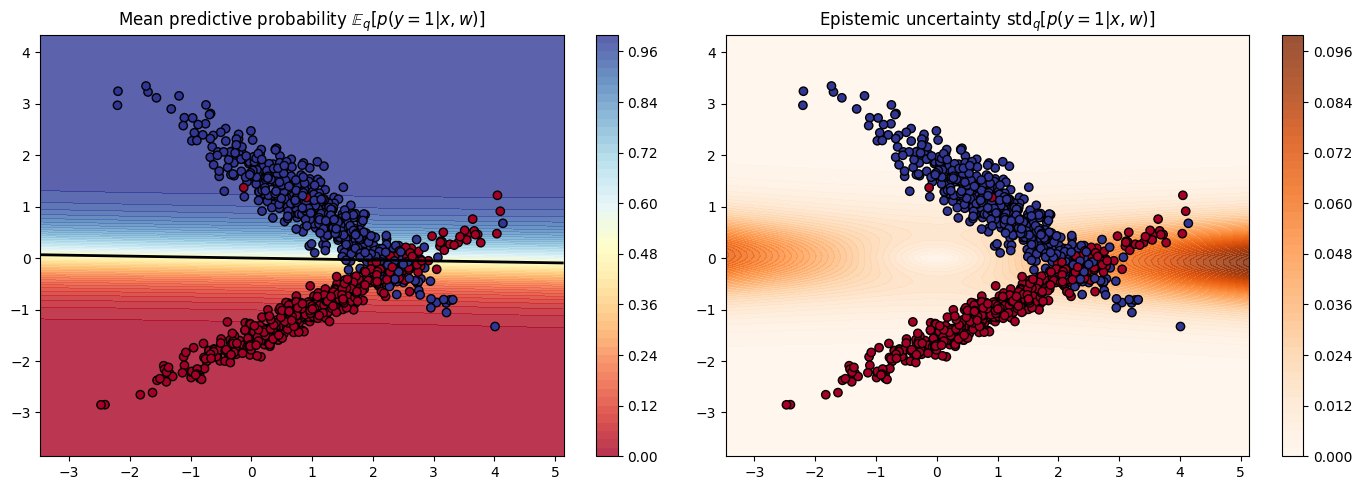

In [7]:

# --- Uncertainty Quantification ---
L_pred = 500  # more samples = smoother uncertainty estimate

xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
                    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)  # (G, D)

with torch.no_grad():
    # Sample L weights from q(w)
    eps = torch.randn(L_pred, D)
    w_samples = m + torch.exp(log_s) * eps          # (L_pred, D)

    # Predict for each sampled weight
    logits = grid @ w_samples.T                      # (G, L_pred)
    probs  = torch.sigmoid(logits)                   # (G, L_pred)

    mean_prob = probs.mean(dim=1).numpy()            # (G,)  -- mean prediction
    std_prob  = probs.std(dim=1).numpy()             # (G,)  -- epistemic uncertainty

mean_prob = mean_prob.reshape(xx.shape)
std_prob  = std_prob.reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean predictive probability (like before, but Bayesian)
cf1 = ax1.contourf(xx, yy, mean_prob, levels=50, cmap='RdYlBu', alpha=0.8)
ax1.scatter(X[:, 0], X[:, 1], c=y.numpy(), edgecolors='k', cmap='RdYlBu')
ax1.contour(xx, yy, mean_prob, levels=[0.5], colors='black', linewidths=2)
plt.colorbar(cf1, ax=ax1)
ax1.set_title("Mean predictive probability $\\mathbb{E}_q[p(y=1|x,w)]$")

# Right: epistemic uncertainty (std across posterior samples)
cf2 = ax2.contourf(xx, yy, std_prob, levels=50, cmap='Oranges', alpha=0.8)
ax2.scatter(X[:, 0], X[:, 1], c=y.numpy(), edgecolors='k', cmap='RdYlBu')
plt.colorbar(cf2, ax=ax2)
ax2.set_title("Epistemic uncertainty $\\mathrm{std}_q[p(y=1|x,w)]$")

plt.tight_layout()
plt.show()

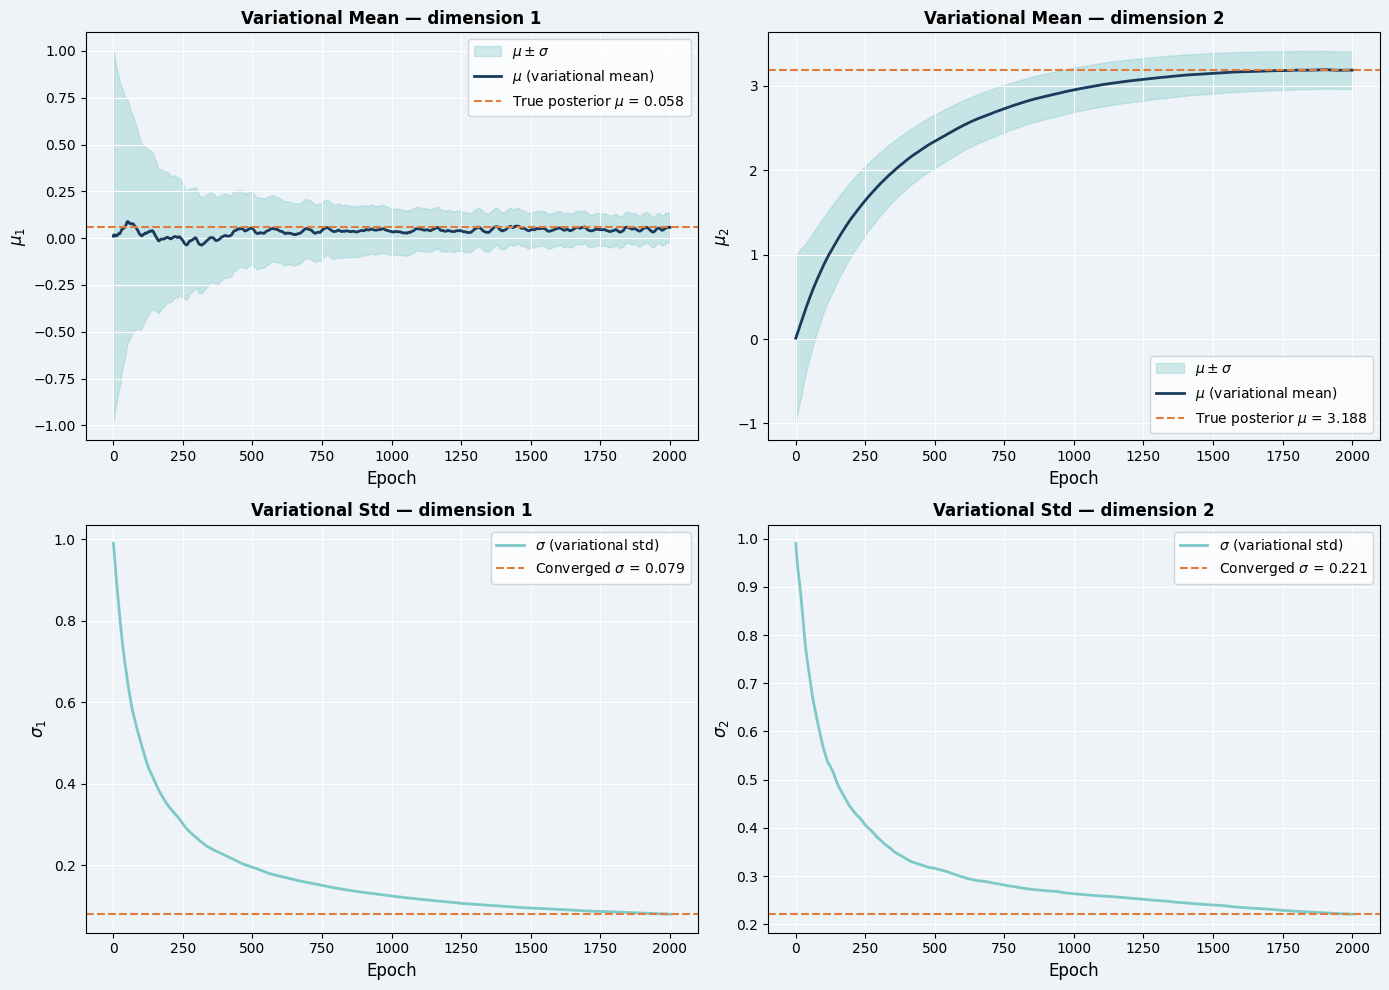

In [8]:
m_history = np.array(m_history)   # (num_epochs, D)
s_history = np.array(s_history)   # (num_epochs, D)

true_posterior_mu = m_history[-1]      # converged mean per dimension
epochs = np.arange(1, num_epochs + 1)  # ← this was missing

fig, axes = plt.subplots(2, D, figsize=(7 * D, 10), facecolor="#eef3f7")

for d in range(D):
        mu_traj = m_history[:, d]
        s_traj  = s_history[:, d]

        ax_mu = axes[0, d] if D > 1 else axes[0]
        ax_mu.set_facecolor("#eef3f7")
        ax_mu.fill_between(epochs, mu_traj - s_traj, mu_traj + s_traj,
                        alpha=0.35, color="#7ec8c8", label=r"$\mu \pm \sigma$")
        ax_mu.plot(epochs, mu_traj, color="#1a3a5c", linewidth=2,
                label=r"$\mu$ (variational mean)")
        ax_mu.axhline(true_posterior_mu[d], color="#e07b39", linestyle="--", linewidth=1.5,
                label=rf"True posterior $\mu$ = {true_posterior_mu[d]:.3f}")
        ax_mu.set_xlabel("Epoch", fontsize=12)
        ax_mu.set_ylabel(rf"$\mu_{d+1}$", fontsize=12)
        ax_mu.set_title(f"Variational Mean — dimension {d+1}", fontweight="bold")
        ax_mu.legend(fontsize=10)
        ax_mu.grid(True, color="white", linewidth=0.8)

        ax_s = axes[1, d] if D > 1 else axes[1]
        ax_s.set_facecolor("#eef3f7")
        ax_s.plot(epochs, s_traj, color="#7ec8c8", linewidth=2,
                label=r"$\sigma$ (variational std)")
        ax_s.axhline(s_traj[-1], color="#e07b39", linestyle="--", linewidth=1.5,
                label=rf"Converged $\sigma$ = {s_traj[-1]:.3f}")
        ax_s.set_xlabel("Epoch", fontsize=12)
        ax_s.set_ylabel(rf"$\sigma_{d+1}$", fontsize=12)
        ax_s.set_title(f"Variational Std — dimension {d+1}", fontweight="bold")
        ax_s.legend(fontsize=10)
        ax_s.grid(True, color="white", linewidth=0.8)

plt.tight_layout()
plt.show()

# 4. Variational AutoEncoder

Since MNIST is discrete dataset

we can use 
​
$$
p_\mathbf{v}(x∣z)=Bernoulli(x;decoder(z))
$$

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()               # Output in [0,1] for pixel values
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick: sample from N(mu, var) using N(0,1)."""
        std = torch.exp(0.5 * logvar)   # Standard deviation
        eps = torch.randn_like(std)      # eps ~ N(0,1)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        # Flatten the image
        x_flat = x.view(x.size(0), -1)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [8]:
batch_size = 128
learning_rate = 1e-3
num_epochs = 20
latent_dim = 20                      # Dimensionality of latent space
input_dim = 28 * 28                   # 784
hidden_dim = 400                      # Size of hidden layer

# Initialize model, optimizer
model = VAE(input_dim, hidden_dim, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [9]:
def loss_function(recon_x, x, mu, logvar):
    """
    VAE loss = reconstruction loss + KL divergence
    - Reconstruction loss: binary cross-entropy (since pixel values are in [0,1])
    - KL divergence: between N(mu, var) and N(0,1)
    """
    # Reconstruction loss (per pixel, summed over all pixels, averaged over batch)
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # KL divergence: see Appendix B of VAE paper
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KL

In [ ]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------- Data Loading --------------------
transform = transforms.Compose([
    transforms.ToTensor(),            # Convert to tensor and scale to [0,1]
])

train_dataset = datasets.MNIST(root='../Data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='../Data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Epoch 1 [0/60000] Loss: 550.5809
Epoch 1 [12800/60000] Loss: 185.1390
Epoch 1 [25600/60000] Loss: 153.2909
Epoch 1 [38400/60000] Loss: 140.6313
Epoch 1 [51200/60000] Loss: 131.9559
====> Epoch 1 Average loss: 163.6323
Epoch 2 [0/60000] Loss: 131.7971
Epoch 2 [12800/60000] Loss: 128.9332
Epoch 2 [25600/60000] Loss: 120.2629
Epoch 2 [38400/60000] Loss: 120.0588
Epoch 2 [51200/60000] Loss: 116.9305
====> Epoch 2 Average loss: 121.3154
Epoch 3 [0/60000] Loss: 113.8462
Epoch 3 [12800/60000] Loss: 115.5504
Epoch 3 [25600/60000] Loss: 112.6954
Epoch 3 [38400/60000] Loss: 113.7222
Epoch 3 [51200/60000] Loss: 110.2442
====> Epoch 3 Average loss: 114.4380
Epoch 4 [0/60000] Loss: 116.1166
Epoch 4 [12800/60000] Loss: 111.6965
Epoch 4 [25600/60000] Loss: 111.1544
Epoch 4 [38400/60000] Loss: 112.5590
Epoch 4 [51200/60000] Loss: 107.3298
====> Epoch 4 Average loss: 111.4993
Epoch 5 [0/60000] Loss: 113.5921
Epoch 5 [12800/60000] Loss: 107.3468
Epoch 5 [25600/60000] Loss: 106.9849
Epoch 5 [38400/60000]

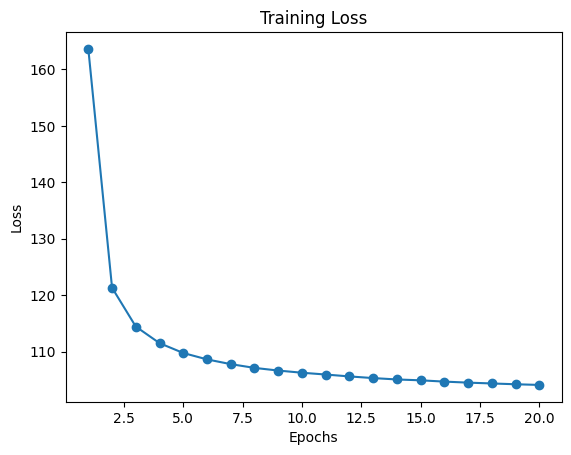

In [10]:
# -------------------- Training Loop --------------------
train_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        total_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch+1} [{batch_idx*len(data)}/{len(train_loader.dataset)}] Loss: {loss.item()/len(data):.4f}')
    
    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f'====> Epoch {epoch+1} Average loss: {avg_loss:.4f}')

# -------------------- Plot Training Loss --------------------
plt.figure()
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

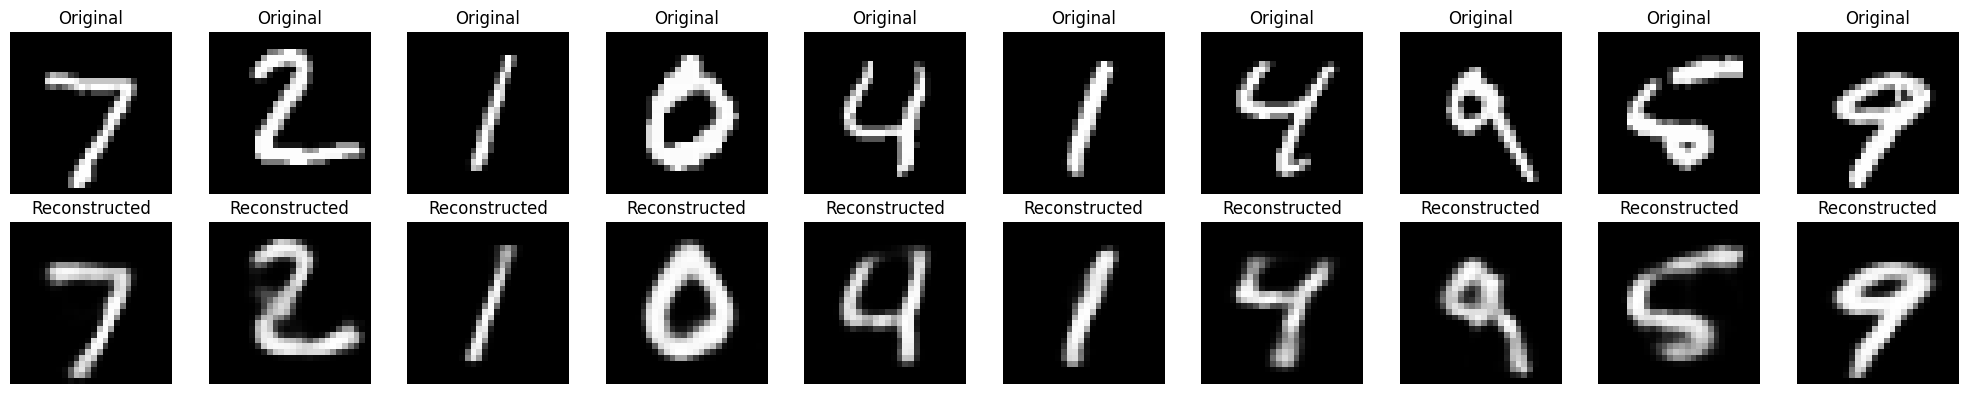

In [11]:
# -------------------- Test: Reconstructions --------------------
model.eval()
with torch.no_grad():
    # Get a batch of test images
    data, _ = next(iter(test_loader))
    data = data.to(device)
    recon, _, _ = model(data)
    
    # Move to CPU for plotting
    data = data.cpu()
    recon = recon.cpu().view(-1, 1, 28, 28)

# Plot original and reconstructed images
n = 10  # number to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(data[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstruction
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(recon[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.tight_layout()
plt.show()

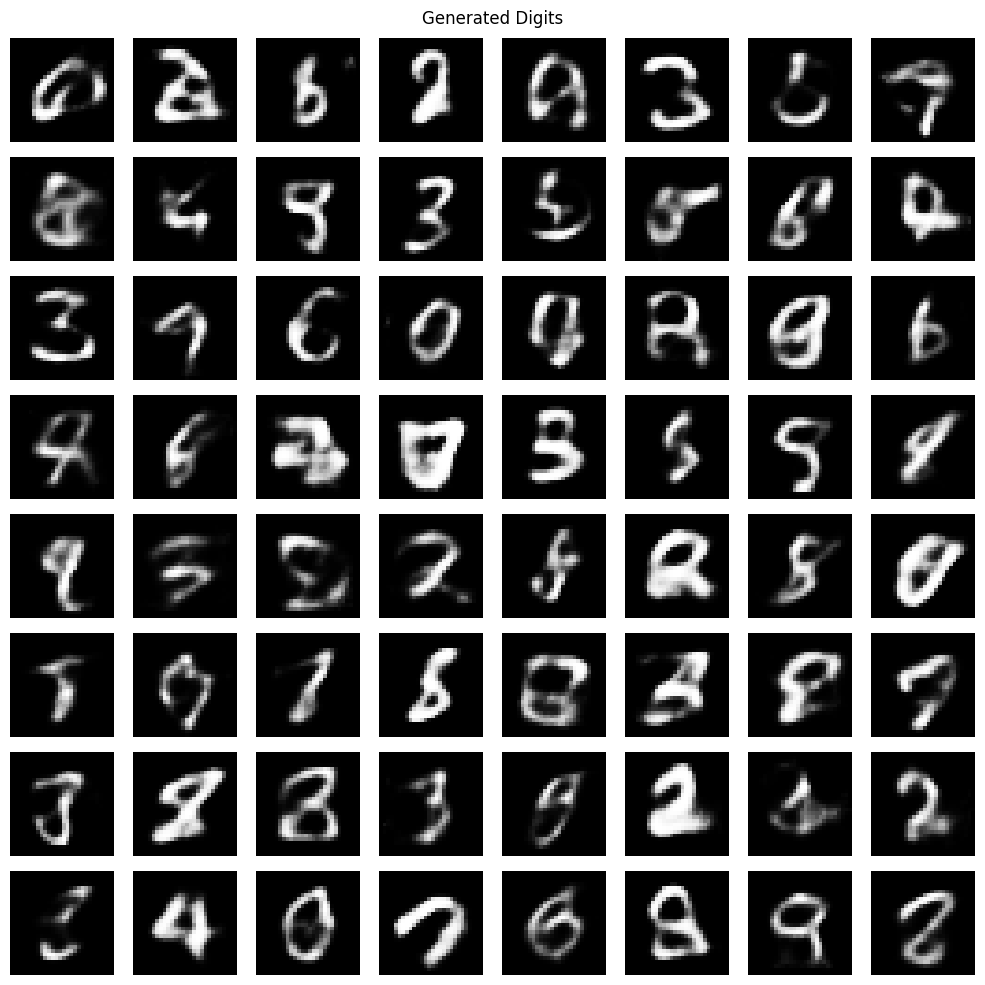

In [12]:
# -------------------- Generate New Digits --------------------
with torch.no_grad():
    # Sample random latent vectors from the prior (standard normal)
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decode(z).cpu().view(-1, 1, 28, 28)

# Plot generated digits
plt.figure(figsize=(10, 10))
for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.imshow(samples[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Generated Digits")
plt.tight_layout()
plt.show()